In [1]:
import numpy as np
import xarray as xr
import netCDF4 as nc
from obspy.core.inventory import inventory
from cryoquake import data_objects as do
from cryoquake import spatial_analysis as sa
from cryoquake import event_calculation as ec
from cryoquake import moment_magnitude as mm
from obspy.core import UTCDateTime, read, Stream, Trace
import matplotlib.pyplot as plt
import obspy
from obspy.signal.filter import envelope
import multiprocessing as mp
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import tqdm
import pandas as pd
import os
from matplotlib.dates import DateFormatter, HourLocator, DayLocator
from obspy.imaging.util import _set_xaxis_obspy_dates
from matplotlib import rcParams
import plotly_resampler
import plotly.graph_objects as go
from plotly_resampler import FigureResampler, FigureWidgetResampler
from obspy.geodetics import degrees2kilometers, kilometers2degrees
from matplotlib.dates import DateFormatter, DayLocator, HourLocator
from scipy.signal import hilbert
from multitaper.mtspec import MTSine, MTSpec
from scipy.optimize import minimize
from scipy.signal.windows import get_window
from scipy.optimize import least_squares
from uncertainties import ufloat
from uncertainties.umath import cos, log10
from obspy.realtime.signal import kurtosis

#rc('text', usetex=True)
rcParams['font.size'] = 8
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial'] 
one_col = 3.35 #inches
two_col = 7.0 #inches

In [2]:
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import matplotlib.pyplot as plt
import numpy as np

# Make custom colormap for BedMachine bed topography
# N.B. using LinearSegmentedColormap to manually set colors at key anchor values, then interpolating inbetween
def cmap_bedmachine():
  colors = [
    (17/256, 29/256, 57/256), # Dark blue
    (59/256, 89/256, 130/256), # Navy blue
    (102/256, 172/256, 222/256), # Baby blue
    (255/256, 255/256, 255/256), # White
    (58/256, 97/256, 39/256), # Dark green
    (93/256, 156/256, 63/256), # Green
    (195/256, 180/256, 79/256), # Yellow
    (107/256, 82/256, 0), # Brown
    (52/256 ,37/256, 0) # Dark brown
  ]
  values = [-3000, -1000, -500, 0, 1, 500, 1000, 1500, 3000]
  norm = plt.Normalize(min(values), max(values))
  cmapping = list(zip(norm(values), colors))
  custom_cmap = LinearSegmentedColormap.from_list(name = 'BedMachine', colors = cmapping)
  return custom_cmap

# Make custom colormap for geological units in GeoMAP
# N.B. Mapping categorical values from column 'LITHCODE' or 'SIMPCODE' to specific colors & then setting them as a colormap via ListedColormap - Simply run print(geomap_data['COL_NAME'].unique()) to see the unique values in each column
def cmap_geomap(category):
  if category == 'LITHCODE':
    # For 'LITHCODE', explicitly set RGBA values (actually according to QGIS styling provided by dataset)
    color_dict = {'': np.array([190/256, 210/256, 255/256, 255/256]),
                  'c': np.array([255/256, 255/256, 0, 255/256]),
                  'j': np.array([76/256, 230/256, 0, 255/256]),
                  'l': np.array([76/256, 230/256, 0, 255/256]),
                  's': np.array([76/256, 230/256, 0, 255/256]),
                  'w': np.array([76/256, 230/256, 0, 255/256]),
                  'a': np.array([255/256, 0, 0, 255/256]),
                  'b': np.array([255/256, 0, 0, 255/256]),
                  'f': np.array([255/256, 0, 0, 255/256]),
                  'v': np.array([255/256, 0, 0, 255/256]),
                  'd': np.array([255/256, 115/256, 223/256, 255/256]),
                  'g': np.array([255/256, 115/256, 223/256, 255/256]),
                  'i': np.array([255/256, 115/256, 223/256, 255/256]),
                  'u': np.array([255/256, 115/256, 223/256, 255/256]),
                  'h': np.array([255/256, 115/256, 223/256, 255/256]),
                  'e': np.array([122/256, 142/256, 245/256, 255/256]),
                  'm': np.array([122/256, 142/256, 245/256, 255/256]),
                  'o': np.array([122/256, 142/256, 245/256, 255/256]),
                  't': np.array([122/256, 142/256, 245/256, 255/256]),
                  'y': np.array([122/256, 142/256, 245/256, 255/256]),
                  'p': np.array([122/256, 142/256, 245/256, 255/256]),
                  'n': np.array([132/256, 0, 168/256, 255/256]),
                  'q': np.array([132/256, 0, 168/256, 255/256]),
                  'x': np.array([132/256, 0, 168/256, 255/256]),
                  'z': np.array([132/256, 0, 168/256, 255/256]),
                  '?': np.array([78/256, 78/256, 78/256, 255/256])}
  elif category == 'SIMPCODE':
    # You can also just set some random named color strings - let's do this for 'SIMPCODE'
    color_dict = {10: 'lightblue',
                  11: 'blue',
                  20: 'turquoise',
                  21: 'green',
                  22: 'forestgreen',
                  23: 'yellowgreen',
                  30: 'yellow',
                  31: 'gold',
                  32: 'orange',
                  40: 'orangered',
                  41: 'coral',
                  42: 'red',
                  43: 'maroon',
                  44: 'brown',
                  45: 'chocolate',
                  50: 'pink',
                  60: 'teal',
                  61: 'violet',
                  62: 'indigo',
                  63: 'grey',
                  70: 'black'}
  else:
    return "Invalid column label given! Pick 'LITHCODE' or 'SIMPCODE'."
  custom_cmap = ListedColormap(list(color_dict.values()))
  return custom_cmap

In [3]:
directory = '/Users/jmagyar/Documents/MappingProducts/'
bedmachine_file = directory + 'BedMachineAntarctica-v3.nc'
groundingline_file = directory + 'GroundingLine_Antarctica_v02.shp'
groundingline_file2 = directory + 'InSAR_GL_Antarctica_v02.shp'
grounding_zone = directory + 'Antarctic_GZ_2018_v01.0.shp'
coastline_file = directory + 'Coastline_Antarctica_v02.shp'
bedmap3_file = directory + 'bedmap3.nc'
bedmap3 = xr.open_dataset(bedmap3_file, engine="netcdf4")

In [4]:
xmin = 2.26e6
xmax = 2.28e6
ymin = -1.01e6
ymax = -9.9e5

resolution = 200

xlin = np.mgrid[xmin:xmax:resolution]
ylin = np.mgrid[ymin:ymax:resolution]

In [5]:
#make a dataset with these coordinates...
bed_grid = xr.Dataset(coords=dict(x=("x", xlin),y=("y", ylin)))
bedmap_interp = bedmap3.interp_like(bed_grid)
bed_grid = bed_grid.assign(dict(bed_topography = bedmap_interp.bed_topography))

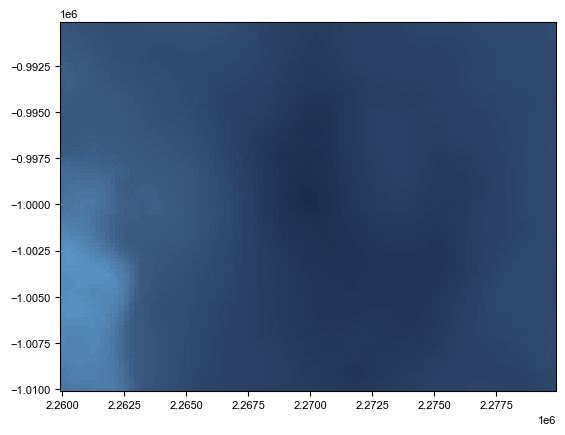

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.pcolormesh(bed_grid.x.values,bed_grid.y.values,bed_grid.bed_topography.values,cmap=cmap_bedmachine(),vmin=-3000,vmax=3000)

In [7]:
t1 = UTCDateTime(2018,12,24)
t2 = UTCDateTime(2019,1,30)

psd_window = 5
psd_overlap = 0.5

chunk = do.SeismicChunk(t1,t2)

path = '/Users/jmagyar/Documents/TottenData'
w_path = os.path.join(path,'stacked_waveforms')
s_path = os.path.join(path,'stations')
c_path = os.path.join(path,'catalogues')
p_path = os.path.join(path,'event_plots')
spec_path = os.path.join(path,'spectrograms')

cloud_path = '/Users/jmagyar/Library/Mobile Documents/com~apple~CloudDocs/Outputs/Icequakes'


inv_files = os.listdir(s_path)

inv = inventory.Inventory()

for file in inv_files:
    temp_path = os.path.join(s_path,file)
    inv += inventory.read_inventory(temp_path,level='response',format='STATIONXML')

inv = inv.remove(station='TI7A')

inv = inv.select(station='TI?A',channel='CH?')

c_path = os.path.join(path,'catalogues')

temp_cat = do.EventCatalogue(t1,t2,os.path.join(c_path),templates=True)

moment_mags = chunk.load_csv(os.path.join(c_path,'network'),'moment_magnitude')
temp_cat.attributes['Mw'] = moment_mags['Mw']
groups = temp_cat.group_split()

In [104]:
df = 500
pol_win = 1.0 #s
freq_smooth = 50
g = 8
sta = 0.5
lta = 5

cluster_num = 39

stream = read(os.path.join(path,'stacked_waveforms','stacked_waveforms_cluster_'+str(cluster_num) + '.mseed'))
stream = stream.filter("bandpass",freqmin=1,freqmax=10)

In [105]:
coal_grid = sa.CoalescenceBedSearch(bed_grid,stream,inv,sta=sta,lta=lta,normalise=True,modulate=True,decimation=10,g=g,smooth=freq_smooth,mod_win=pol_win,mod_overlap=0.95,p_detect='radial_self',s_detect=None)

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/jmagyar/Documents/icequakecode/cryoquake/src/cryoquake/spatial_analysis.py:642: FutureWarning: This function is deprecated. See: https://py

ValueError: too many values to unpack (expected 2)

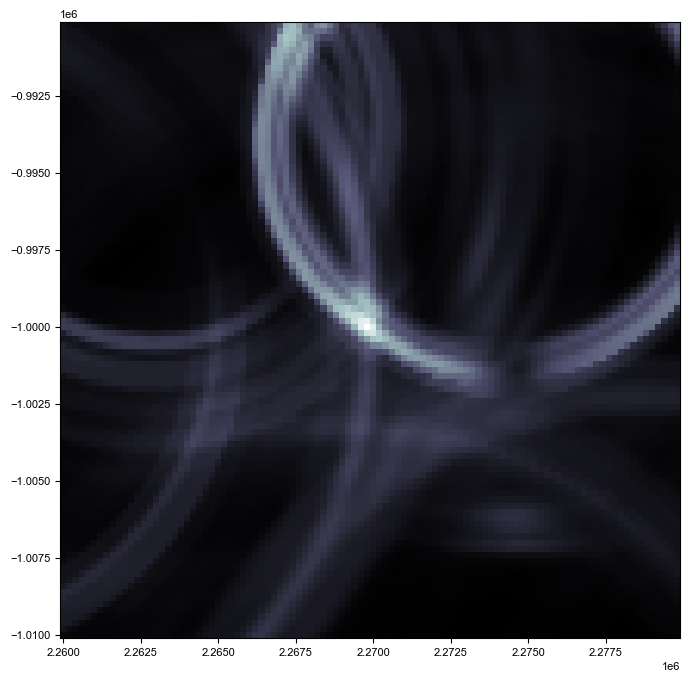

In [78]:
fig = plt.figure(figsize=(8,8))

ne_ax = fig.add_subplot(111)

coal = coal_grid.coalescence.values

x_ind, y_ind, t_ind = np.unravel_index(np.argmax(coal),coal.shape)

#stacked_coalescence = np.max(summed_PS_obj,axis=(0,1,2))
#t_ind = np.argmax(stacked_coalescence)

coal_slice = coal[:,:,t_ind]


#ne_ax.pcolormesh(x,y,np.sum(coal_slice,axis=2).T,cmap='bone')
#nz_ax.pcolormesh(z,y,np.sum(coal_slice,axis=0),cmap='bone')
#ez_ax.pcolormesh(x,z,np.sum(coal_slice,axis=1).T,cmap='bone')

ne_ax.pcolormesh(xlin,ylin,coal_slice.T,cmap='bone')

#ne_ax.plot(x_fit,y_fit,marker='X',color='black')
#nz_ax.plot(z_fit,y_fit,marker='X',color='black')
#ez_ax.plot(x_fit,z_fit,marker='X',color='black')

In [80]:
coal_path = '/Users/jmagyar/Documents/TottenData/coalescence'

coal_grid = xr.load_dataset(os.path.join(coal_path,'P_coalescence_function_'+str(44))+'.nc')

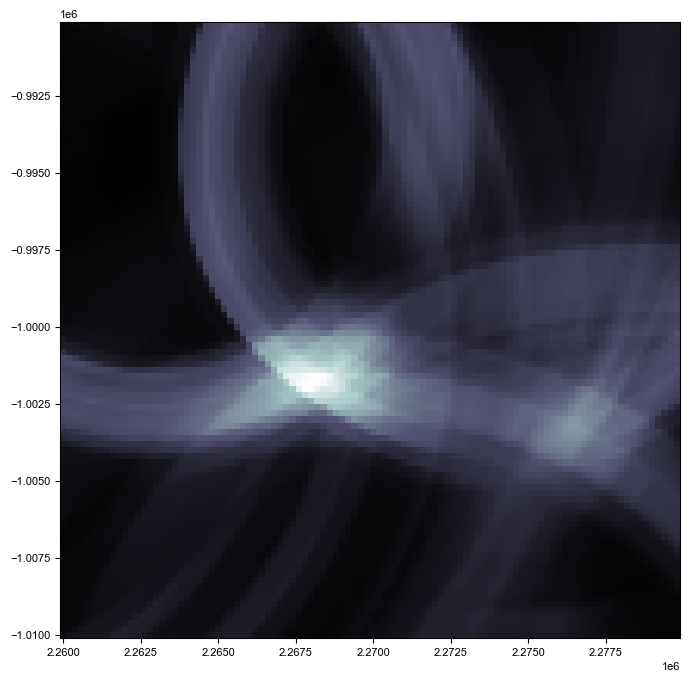

In [81]:
fig = plt.figure(figsize=(8,8))

ne_ax = fig.add_subplot(111)

coal = coal_grid.coalescence.values

x_ind, y_ind, t_ind = np.unravel_index(np.argmax(coal),coal.shape)

#stacked_coalescence = np.max(summed_PS_obj,axis=(0,1,2))
#t_ind = np.argmax(stacked_coalescence)

coal_slice = coal[:,:,t_ind]


#ne_ax.pcolormesh(x,y,np.sum(coal_slice,axis=2).T,cmap='bone')
#nz_ax.pcolormesh(z,y,np.sum(coal_slice,axis=0),cmap='bone')
#ez_ax.pcolormesh(x,z,np.sum(coal_slice,axis=1).T,cmap='bone')

ne_ax.pcolormesh(xlin,ylin,coal_slice.T,cmap='bone')

#ne_ax.plot(x_fit,y_fit,marker='X',color='black')
#nz_ax.plot(z_fit,y_fit,marker='X',color='black')
#ez_ax.plot(x_fit,z_fit,marker='X',color='black')

In [34]:
#can I save the coalescence as a netcdf using xarray? More consistent way of dealing with it...

coal_ds = xr.Dataset(
    data_vars=dict(coalescence = (["x","y","t"],coal[:,:,0,:]), bed_elevation = (["x","y"],Zgrid[:,:,0])),
    coords=dict(
        x=("x", xlin),
        y=("y", ylin),
        t=("t",t)))

In [35]:
coal_ds

<xarray.Dataset> Size: 561MB
Dimensions:        (x: 200, y: 200, t: 1751)
Coordinates:
  * x              (x) float64 2kB 2.26e+06 2.26e+06 ... 2.28e+06 2.28e+06
  * y              (y) float64 2kB -1.01e+06 -1.01e+06 ... -9.902e+05 -9.901e+05
  * t              (t) float64 14kB 0.0 0.02 0.04 0.06 ... 34.96 34.98 35.0
Data variables:
    coalescence    (x, y, t) float64 560MB 0.01137 0.01215 0.01342 ... 0.0 0.0
    bed_elevation  (x, y) float64 320kB -823.0 -817.2 ... -1.424e+03 -1.422e+03

In [8]:
#make lookup tables for each station, then use these for travel time inversion...

sta_xy = sa.EPSGStations(inv)

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/jmagyar/Documents/icequakecode/cryoquake/src/cryoquake/spatial_analysis.py:642: FutureWarning: This function is deprecated. See: https://py

In [10]:
import pyproj
proj_wgs84 = pyproj.Proj(init="epsg:4326")
proj_epsg3031 = pyproj.Proj(init="epsg:3031")

/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/jmagyar/opt/miniconda3/envs/seismo_analysis/lib/python3.11/site-packages/pyproj/crs/crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [108]:
bed_grid = xr.Dataset(coords=dict(x=("x", xlin),y=("y", ylin)))
bedmap_interp = bedmap3.interp_like(bed_grid)
bed_grid = bed_grid.assign(dict(bed_topography = bedmap_interp.bed_topography))

lu_table = xr.Dataset(coords=dict(x=xlin,y=ylin))

for network in inv:
    for station in network:
        lat, lon, sta_z, = station.latitude,station.longitude,station.elevation
        sta_x, sta_y = pyproj.transform(proj_wgs84, proj_epsg3031, lon, lat)

        dist = ((lu_table.x - sta_x)**2 + (lu_table.y - sta_y)**2 + (bed_grid.bed_topography - sta_z)**2)**(0.5)
        tt = dist / 3900
        lu_table = lu_table.assign({station.code:tt})




/var/folders/z4/gw28hj796zjdxt4nltp_h5g1m6cl00/T/ipykernel_58691/348544386.py:10: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  sta_x, sta_y = pyproj.transform(proj_wgs84, proj_epsg3031, lon, lat)


In [109]:
lu_table

<xarray.Dataset> Size: 402kB
Dimensions:  (x: 100, y: 100)
Coordinates:
  * x        (x) float64 800B 2.26e+06 2.26e+06 2.26e+06 ... 2.28e+06 2.28e+06
  * y        (y) float64 800B -1.01e+06 -1.01e+06 ... -9.904e+05 -9.902e+05
Data variables:
    TI4A     (x, y) float64 80kB 3.021 3.051 3.081 3.112 ... 7.246 7.294 7.341
    TI3A     (x, y) float64 80kB 5.432 5.393 5.355 5.317 ... 1.808 1.834 1.861
    TI8A     (x, y) float64 80kB 2.888 2.842 2.796 2.751 ... 6.822 6.84 6.859
    TI6A     (x, y) float64 80kB 4.257 4.206 4.156 4.105 ... 4.416 4.425 4.436
    TI1A     (x, y) float64 80kB 5.077 5.094 5.112 5.131 ... 6.702 6.754 6.805

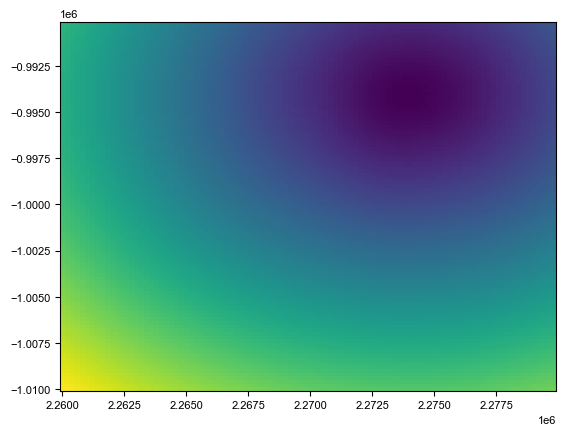

In [110]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.pcolormesh(lu_table.x,lu_table.y,lu_table.TI3A.T)

In [121]:
from obspy.signal.trigger import ar_pick

thresh = 5
min_t = 6

df = 500
pol_win = 1.0 #s
freq_smooth = 50
g = 8
sta = 0.5
lta = 5
mod_overlap = 0.95

cluster_labels = []
rows = []

for cluster_num in groups.keys():

    cluster_labels.append(cluster_num)

    stream = read(os.path.join(w_path,'stacked_waveforms_cluster_' + str(cluster_num) + '.mseed'))
    stream = stream.filter('bandpass',freqmin=1,freqmax=10) 

    Z_lst = []
    N_lst = []
    E_lst = []
    sta_lst = []

    P_dict = {}

    for network in inv:
        for station in network:
            Z = stream.select(station=station.code,component='Z')[0].data
            N = stream.select(station=station.code,component='1')[0].data
            E = stream.select(station=station.code,component='2')[0].data

            Z, N, E = sa.RollingStreamModulation(Z,N,E,int(pol_win*df),g=g,smooth=freq_smooth,overlap=mod_overlap)
                
            Z_lst.append(Z)
            N_lst.append(N)
            E_lst.append(E)
            sta_lst.append(station.code)

            #P_t, _ = ar_pick(Z,N,E, df,
            #             1.0, 10.0, 5.0, 1.0, 4.0, 1.0, 2, 8, 0.5, 0.2)

            cf = sa.Onset_Function(Z,N,E,int(sta*df),int(lta*df),mode='absolute')

            if np.isnan(cf).any():
                P_t = np.nan
            else:
                cf[0:min_t*df] = 0
                cf[-min_t*df:] = 0
                trigger = np.argmax(cf)
                #trigger = np.where(cf > thresh)[0]
                P_t = trigger / df
            print(station.code,P_t)

            P_dict[station.code] = P_t
    rows.append(P_dict)


TI4A 11.476
TI3A 9.742
TI8A 11.034
TI6A 9.74
TI1A 12.186
TI4A 9.466
TI3A 6.98
TI8A 10.248
TI6A 9.624
TI1A 12.538
TI4A 10.396
TI3A 8.79
TI8A 9.406
TI6A 8.794
TI1A 10.82


KeyboardInterrupt: 

In [94]:
#eventually will have a misfit dataset...
tlin = np.mgrid[0:10:0.1]

misfit_grid = xr.Dataset(coords=dict(x=("x", xlin),y=("y", ylin),t=("t",tlin)))


In [100]:
misfit_arr = np.zeros((xlin.size,ylin.size,tlin.size))

for i, t in enumerate(misfit_grid.t.values):

    arrival = t + lu_table
    for sta_code, P_t in P_dict.items():
        misfit_t = (arrival.variables[sta_code] - P_t)**2
        if ~np.isnan(misfit_t).any():
            misfit_arr[:,:,i] += (arrival.variables[sta_code] - P_t)**2
    #misfit_arr[:,:,i] = ...

    misfit_xr = xr.DataArray(misfit_arr,coords=dict(x=("x", xlin),y=("y", ylin),t=("t",tlin)))

misfit_grid = misfit_grid.assign((dict(error = misfit_xr)))

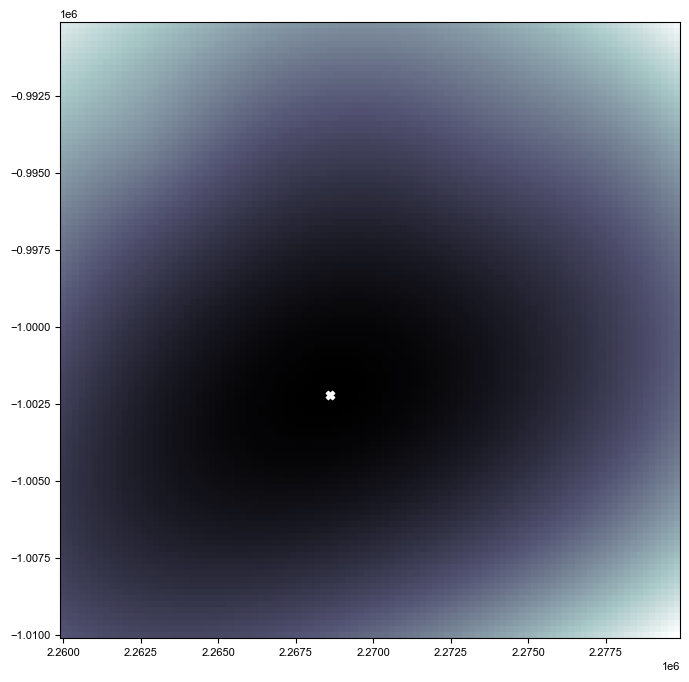

In [101]:
fig = plt.figure(figsize=(8,8))

ne_ax = fig.add_subplot(111)

misfit = misfit_grid.error.values

x_ind, y_ind, t_ind = np.unravel_index(np.argmin(misfit),misfit.shape)

#stacked_coalescence = np.max(summed_PS_obj,axis=(0,1,2))
#t_ind = np.argmax(stacked_coalescence)

misfit_slice = misfit[:,:,t_ind]

x_loc = xlin[x_ind]
y_loc = ylin[y_ind]



#ne_ax.pcolormesh(x,y,np.sum(coal_slice,axis=2).T,cmap='bone')
#nz_ax.pcolormesh(z,y,np.sum(coal_slice,axis=0),cmap='bone')
#ez_ax.pcolormesh(x,z,np.sum(coal_slice,axis=1).T,cmap='bone')

ne_ax.pcolormesh(xlin,ylin,misfit_slice.T,cmap='bone')

ne_ax.scatter(x_loc,y_loc,color='white',marker='X')

#ne_ax.plot(x_fit,y_fit,marker='X',color='black')
#nz_ax.plot(z_fit,y_fit,marker='X',color='black')
#ez_ax.plot(x_fit,z_fit,marker='X',color='black')